In [ ]:
from eeg_music.data import EEGMusicDataset
from pathlib import Path
ds = EEGMusicDataset.load_ondisk(Path("./datasets/bcmi_preprocessed/bcmi_full_ica_40ch/"))
onesubj_ds = EEGMusicDataset.load_ondisk(Path("./datasets/bcmi_preprocessed/bcmi_onesubj_ica_40ch/"))
len(ds)

/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


3456

In [2]:
splitted = ds.subject_wise_split(p_train=0.7, p_val=0.0)
train_ds, test_ds = splitted["train"], splitted["test"]
len(train_ds), len(test_ds)

(2304, 1152)

In [ ]:
splitted = onesubj_ds.subject_wise_split(p_train=0.7, p_val=0.0)
train_ds_1, test_ds_1 = splitted["train"], splitted["test"]
len(train_ds_1), len(test_ds_1)

In [4]:
# alternatively
train_ds = EEGMusicDataset.load_ondisk(Path("./datasets/bcmi_preprocessed/bcmi_train_onesubj_ica_40ch/"))
test_ds = EEGMusicDataset.load_ondisk(Path("./datasets/bcmi_preprocessed/bcmi_test_onesubj_ica_40ch/"))
len(train_ds), len(test_ds), train_ds[0]

(432,
 432,
 TrialData(dataset='bcmi-training', subject='10', session='3', run='1', trial_id='trial_1', music_filename=MusicFilename(filename='1-6_3_first.wav'), eeg_data=OnDiskArrayEeg(filepath=PosixPath('datasets/bcmi_preprocessed/bcmi_train_onesubj_ica_40ch/eeg/bcmi-training/10/3/1/trial_1/eeg.npz')), music_data=OnDiskMusic(filepath=PosixPath('datasets/bcmi_preprocessed/bcmi_train_onesubj_ica_40ch/stimuli/bcmi-training/1-6_3_first.wav'))))

In [3]:
from eeg_music.data import MappedDataset
from eeg_music.onset_conversion import trial_wavraw_to_noteonsets

nds = MappedDataset(ds, trial_wavraw_to_noteonsets)

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [4]:
nds[0].eeg_data.get_array().data.shape

(40, 181)

In [4]:
from fractions import Fraction
from eeg_music.data import ArrayStratifiedSamplingDataset

# train_ds_strat = ArrayStratifiedSamplingDataset(train_ds, 10, trial_length_secs=Fraction(1, 1))
# test_ds_strat =  ArrayStratifiedSamplingDataset(test_ds, 10, trial_length_secs=Fraction(1, 1))

In [5]:
def after_loaded(ds):
  nds = MappedDataset(ds, trial_wavraw_to_noteonsets)
  return ArrayStratifiedSamplingDataset(nds, 10, trial_length_secs=Fraction(10, 1))

In [6]:
train_ds_strat = after_loaded(train_ds)
test_ds_strat = after_loaded(test_ds)

In [ ]:
train_ds_strat_1 = after_loaded(train_ds_1)
test_ds_strat_1 = after_loaded(test_ds_1)

In [15]:
m_train_ds = after_loaded(train_ds)
m_train_ds[0].music_data.onset_times

array([0.7287982, 1.6111565, 2.389025 , 3.2713833, 4.2582316, 5.2450795,
       6.2435374, 6.963356 , 8.019864 , 8.797732 , 9.772971 ],
      dtype=float32)

In [16]:
lengths = sorted(len(t.music_data.onset_times) for t in train_ds_strat)
if not lengths:
  print("No samples in train_ds_strat")
else:
  n = len(lengths)
  median = lengths[n//2] if n % 2 else (lengths[n//2 - 1] + lengths[n//2]) / 2
  print("Median onset count:", median)

Median onset count: 18.0


In [7]:
import numpy as np
def create_X_y(dataset):
    # works for RepeatedDataset(ArrayStratifiedSamplingDataset(ds))
    X = []
    y = []
    for i in range(len(dataset)):
        sample = dataset[i]
        X.append(sample.eeg_data.get_array().data)
        y.append( 1 if len(sample.music_data.onset_times) >= 18.0 else 0 )
    return np.array(X), np.array(y)

# X_train, y_train = create_X_y(train_ds_strat)
# X_train.shape, y_train.shape 

In [8]:
from eeg_music.data import RepeatedDataset

# train_ds_repeated = RepeatedDataset(train_ds_strat, 2)
# test_ds_repeated = RepeatedDataset(test_ds_strat, 2)

X_train, y_train = create_X_y(train_ds_strat)
X_test, y_test = create_X_y(test_ds_strat)
# X_train_prev, y_train_prev = X_train, y_train
# X_test_prev, y_test_prev = X_test, y_test
# X_train, y_train = create_X_y(train_ds_strat_1)
# X_test, y_test = create_X_y(test_ds_strat_1)

In [9]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Flatten EEG data for traditional ML models (samples, channels, timepoints) -> (samples, features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Training set: {X_train_flat.shape}, Labels: {y_train.shape}")
print(f"Test set: {X_test_flat.shape}, Labels: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Training set: (23040, 4000), Labels: (23040,)
Test set: (11520, 4000), Labels: (11520,)
Number of classes: 2


In [10]:
# Train XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test_flat)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"\nXGBoost Test Accuracy: {xgb_accuracy:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost...

XGBoost Test Accuracy: 0.4981

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.48      0.49      5680
           1       0.50      0.51      0.51      5840

    accuracy                           0.50     11520
   macro avg       0.50      0.50      0.50     11520
weighted avg       0.50      0.50      0.50     11520



In [ ]:
# Train SVM
print("Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_flat)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"\nSVM Test Accuracy: {svm_accuracy:.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

Training SVM...


In [ ]:
# Train KNN
from sklearn.neighbors import KNeighborsClassifier
print("Training KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_knn = knn_model.predict(X_test_flat)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"\nKNN Test Accuracy: {knn_accuracy:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

Training KNN...

KNN Test Accuracy: 0.5088

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      5671
           1       0.51      0.56      0.54      5849

    accuracy                           0.51     11520
   macro avg       0.51      0.51      0.51     11520
weighted avg       0.51      0.51      0.51     11520



In [ ]:
# Compare results
print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"SVM Accuracy:     {svm_accuracy:.4f}")
print(f"KNN Accuracy:     {knn_accuracy:.4f}")


COMPARISON
XGBoost Accuracy: 0.5407
SVM Accuracy:     0.5093
KNN Accuracy:     0.5264


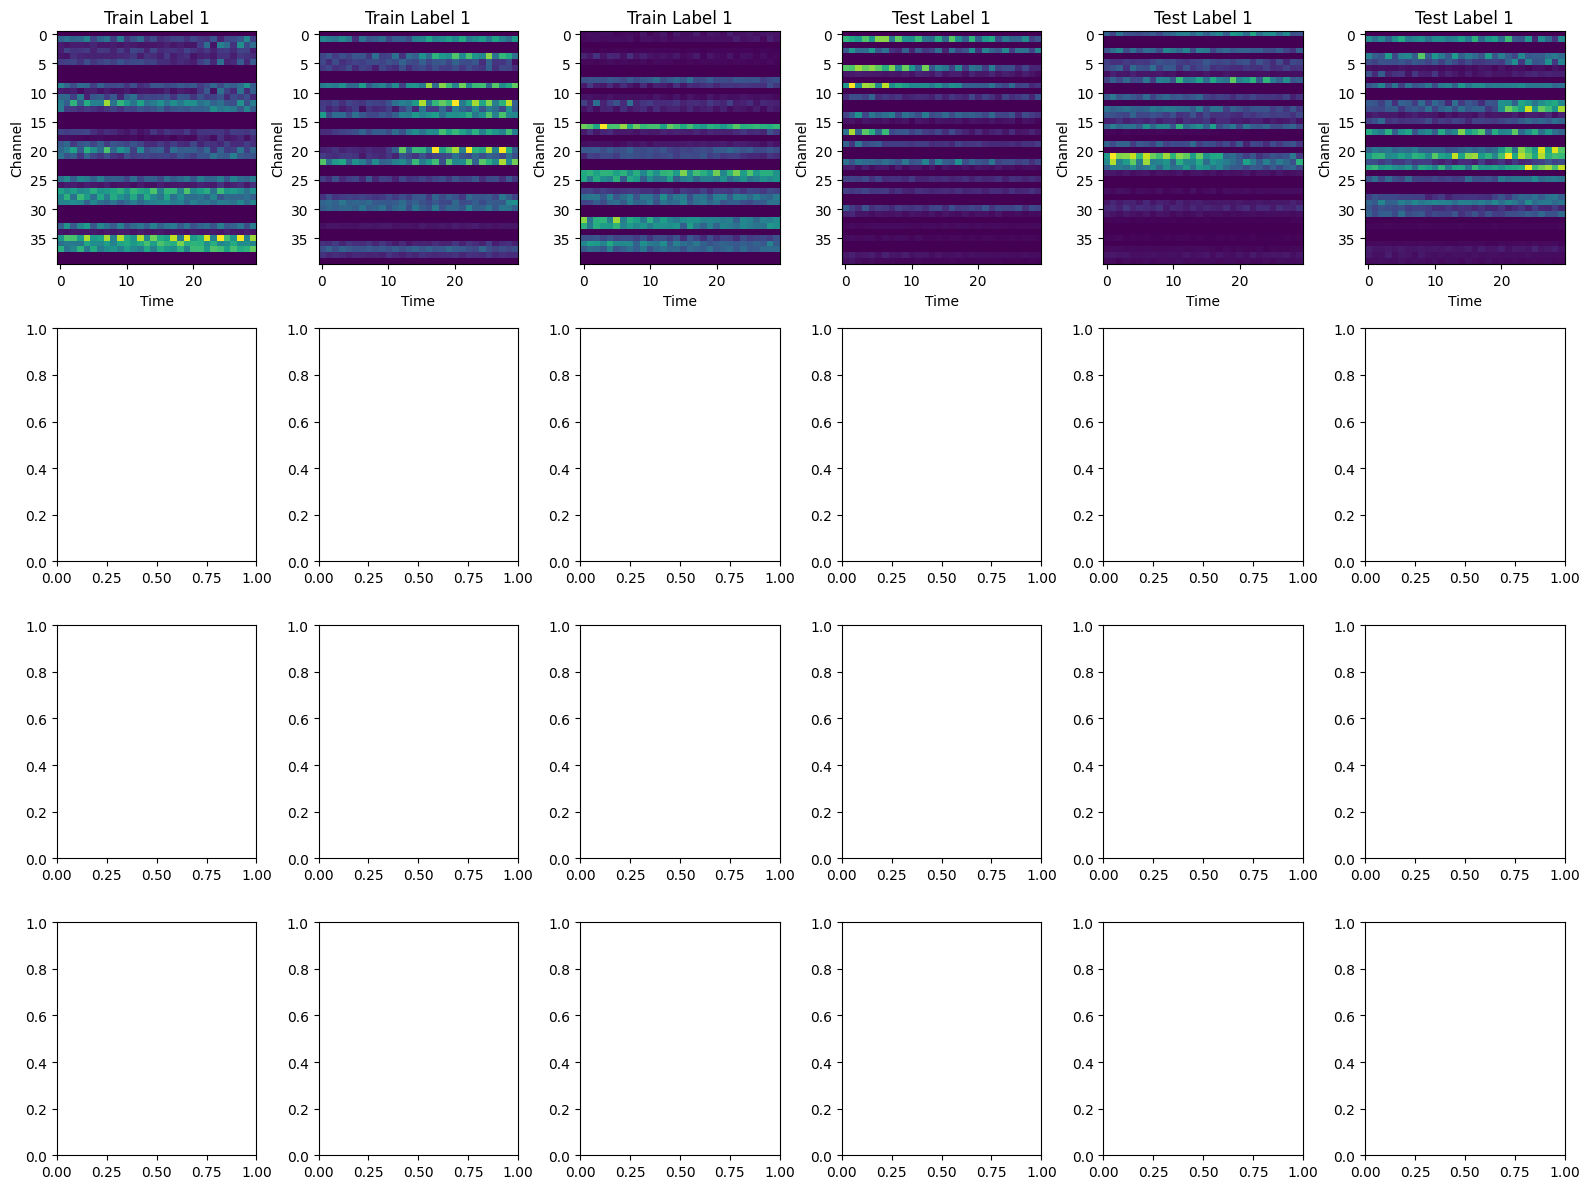

In [39]:
import matplotlib.pyplot as plt


labels_to_plot = [1, 3, 5, 7]
samples_per_label = 3

fig, axes = plt.subplots(len(labels_to_plot), 2*samples_per_label, figsize=(16, 12))

for row, label in enumerate(labels_to_plot):
    # Get train samples with this label
    train_label_indices = np.where(y_train == label)[0]
    train_sampled = np.random.choice(train_label_indices, min(samples_per_label, len(train_label_indices)), replace=False)
    
    # Get test samples with this label
    test_label_indices = np.where(y_test == label)[0]
    test_sampled = np.random.choice(test_label_indices, min(samples_per_label, len(test_label_indices)), replace=False)
    
    # Plot train samples (left side)
    for col, idx in enumerate(train_sampled):
        axes[row, col].imshow(X_train[idx], aspect='auto', interpolation='nearest', cmap='viridis')
        axes[row, col].set_title(f"Train Label {label}")
        axes[row, col].set_xlabel("Time")
        axes[row, col].set_ylabel("Channel")
    
    # Plot test samples (right side)
    for col, idx in enumerate(test_sampled):
        axes[row, samples_per_label + col].imshow(X_test[idx], aspect='auto', interpolation='nearest', cmap='viridis')
        axes[row, samples_per_label + col].set_title(f"Test Label {label}")
        axes[row, samples_per_label + col].set_xlabel("Time")
        axes[row, samples_per_label + col].set_ylabel("Channel")

plt.tight_layout()
plt.show()